In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

In [5]:
df = pd.read_csv('dataset.csv', delimiter=',')

In [22]:
df.head()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,Date
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3.0,...,4,3.0,4.0,4,5,5,25,18.0,neutral or dissatisfied,2022-10-20
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3.0,...,1,5.0,3.0,1,4,1,1,6.0,neutral or dissatisfied,2022-10-08
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2.0,...,4,3.0,4.0,4,4,5,0,0.0,satisfied,2022-10-11
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5.0,...,2,5.0,3.0,1,4,2,11,9.0,neutral or dissatisfied,2022-10-25
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3.0,...,3,4.0,4.0,3,3,3,0,0.0,satisfied,2022-10-23


In [26]:
print(df.isnull().sum())

id                                   0
Gender                               0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Inflight wifi service                0
Departure/Arrival time convenient    0
Ease of Online booking               0
Gate location                        0
Food and drink                       0
Online boarding                      0
Seat comfort                         0
Inflight entertainment               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Inflight service                     0
Cleanliness                          0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
satisfaction                         0
Date                                 0
dtype: int64


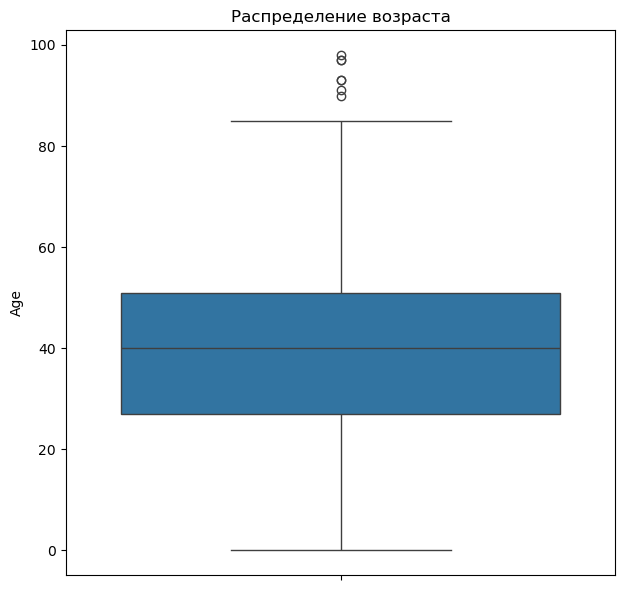

In [91]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(y=df['Age'])
plt.title("Распределение возраста")
plt.tight_layout()
plt.show()

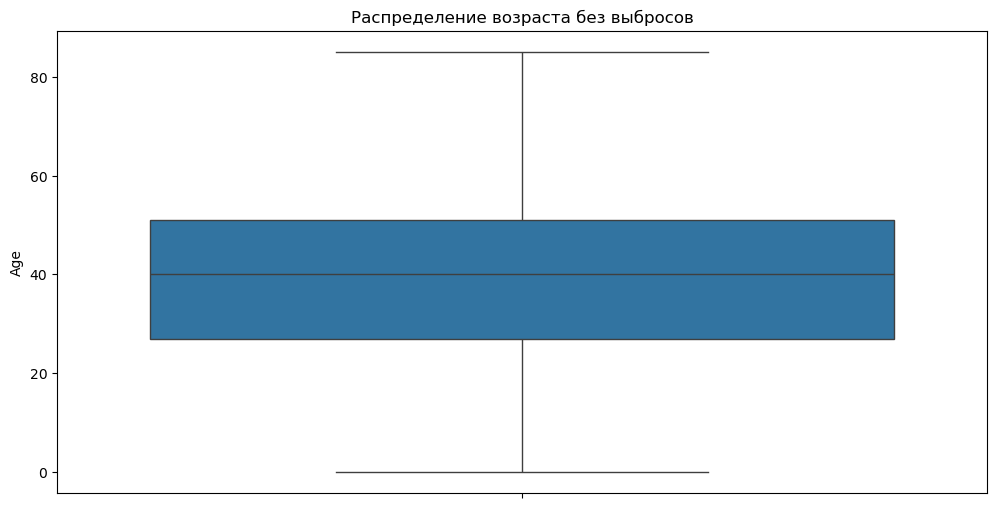

In [80]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_no_outliers = df[(df['Age'] >= lower_bound) & (df['Age'] <= upper_bound)]

plt.figure(figsize=(12, 6))
sns.boxplot(y=df_no_outliers['Age'])
plt.title("Распределение возраста без выбросов")
plt.show()

In [13]:
df['Leg room service'] = df['Leg room service'].fillna(df['Leg room service'].median())

In [15]:
df['Baggage handling'] = df['Baggage handling'].fillna(df['Baggage handling'].median())

In [18]:
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].median())

In [25]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

In [23]:
df.head()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,Date
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3.0,...,4,3.0,4.0,4,5,5,25,18.0,neutral or dissatisfied,2022-10-20
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3.0,...,1,5.0,3.0,1,4,1,1,6.0,neutral or dissatisfied,2022-10-08
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2.0,...,4,3.0,4.0,4,4,5,0,0.0,satisfied,2022-10-11
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5.0,...,2,5.0,3.0,1,4,2,11,9.0,neutral or dissatisfied,2022-10-25
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3.0,...,3,4.0,4.0,3,3,3,0,0.0,satisfied,2022-10-23
5,111157,Female,Loyal Customer,26,Personal Travel,Eco,1180,3,4,2.0,...,3,4.0,4.0,4,4,1,0,0.0,neutral or dissatisfied,2022-10-10
6,82113,Male,Loyal Customer,47,Personal Travel,Eco,1276,2,4,2.0,...,3,3.0,4.0,3,5,2,9,23.0,neutral or dissatisfied,2022-10-07
7,96462,Female,Loyal Customer,52,Business travel,Business,2035,4,3,4.0,...,5,5.0,5.0,4,5,4,4,0.0,satisfied,2022-10-11
8,79485,Female,Loyal Customer,41,Business travel,Business,853,1,2,2.0,...,1,2.0,1.0,4,1,2,0,0.0,neutral or dissatisfied,2022-10-28
9,65725,Male,disloyal Customer,20,Business travel,Eco,1061,3,3,3.0,...,2,3.0,4.0,4,3,2,0,0.0,neutral or dissatisfied,2022-10-14


In [27]:
le = LabelEncoder()
df['Customer_Label'] = le.fit_transform(df['Customer Type'])

In [28]:
df.head()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,Date,Customer_Label
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3.0,...,3.0,4.0,4,5,5,25,18.0,neutral or dissatisfied,2022-10-20,1
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3.0,...,5.0,3.0,1,4,1,1,6.0,neutral or dissatisfied,2022-10-08,2
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2.0,...,3.0,4.0,4,4,5,0,0.0,satisfied,2022-10-11,1
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5.0,...,5.0,3.0,1,4,2,11,9.0,neutral or dissatisfied,2022-10-25,1
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3.0,...,4.0,4.0,3,3,3,0,0.0,satisfied,2022-10-23,1


In [29]:
le = LabelEncoder()
df['Gender_Label'] = le.fit_transform(df['Gender'])

In [30]:
df.head()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,Date,Customer_Label,Gender_Label
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3.0,...,4.0,4,5,5,25,18.0,neutral or dissatisfied,2022-10-20,1,1
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3.0,...,3.0,1,4,1,1,6.0,neutral or dissatisfied,2022-10-08,2,1
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2.0,...,4.0,4,4,5,0,0.0,satisfied,2022-10-11,1,0
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5.0,...,3.0,1,4,2,11,9.0,neutral or dissatisfied,2022-10-25,1,0
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3.0,...,4.0,3,3,3,0,0.0,satisfied,2022-10-23,1,1


In [34]:
le = LabelEncoder()
df['Type_of_Travel_Label'] = le.fit_transform(df['Type of Travel'])

In [35]:
df.head(10)

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,Date,Customer_Label,Gender_Label,Type_of_Travel_Label
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3.0,...,4,5,5,25,18.0,neutral or dissatisfied,2022-10-20,1,1,1
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3.0,...,1,4,1,1,6.0,neutral or dissatisfied,2022-10-08,2,1,0
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2.0,...,4,4,5,0,0.0,satisfied,2022-10-11,1,0,0
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5.0,...,1,4,2,11,9.0,neutral or dissatisfied,2022-10-25,1,0,0
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3.0,...,3,3,3,0,0.0,satisfied,2022-10-23,1,1,0
5,111157,Female,Loyal Customer,26,Personal Travel,Eco,1180,3,4,2.0,...,4,4,1,0,0.0,neutral or dissatisfied,2022-10-10,1,0,1
6,82113,Male,Loyal Customer,47,Personal Travel,Eco,1276,2,4,2.0,...,3,5,2,9,23.0,neutral or dissatisfied,2022-10-07,1,1,1
7,96462,Female,Loyal Customer,52,Business travel,Business,2035,4,3,4.0,...,4,5,4,4,0.0,satisfied,2022-10-11,1,0,0
8,79485,Female,Loyal Customer,41,Business travel,Business,853,1,2,2.0,...,4,1,2,0,0.0,neutral or dissatisfied,2022-10-28,1,0,0
9,65725,Male,disloyal Customer,20,Business travel,Eco,1061,3,3,3.0,...,4,3,2,0,0.0,neutral or dissatisfied,2022-10-14,2,1,0


In [36]:
le = LabelEncoder()
df['Class_Label'] = le.fit_transform(df['Class'])

In [38]:
df.head(10)

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,Date,Customer_Label,Gender_Label,Type_of_Travel_Label,Class_Label
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3.0,...,5,5,25,18.0,neutral or dissatisfied,2022-10-20,1,1,1,3
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3.0,...,4,1,1,6.0,neutral or dissatisfied,2022-10-08,2,1,0,1
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2.0,...,4,5,0,0.0,satisfied,2022-10-11,1,0,0,1
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5.0,...,4,2,11,9.0,neutral or dissatisfied,2022-10-25,1,0,0,1
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3.0,...,3,3,0,0.0,satisfied,2022-10-23,1,1,0,1
5,111157,Female,Loyal Customer,26,Personal Travel,Eco,1180,3,4,2.0,...,4,1,0,0.0,neutral or dissatisfied,2022-10-10,1,0,1,2
6,82113,Male,Loyal Customer,47,Personal Travel,Eco,1276,2,4,2.0,...,5,2,9,23.0,neutral or dissatisfied,2022-10-07,1,1,1,2
7,96462,Female,Loyal Customer,52,Business travel,Business,2035,4,3,4.0,...,5,4,4,0.0,satisfied,2022-10-11,1,0,0,1
8,79485,Female,Loyal Customer,41,Business travel,Business,853,1,2,2.0,...,1,2,0,0.0,neutral or dissatisfied,2022-10-28,1,0,0,1
9,65725,Male,disloyal Customer,20,Business travel,Eco,1061,3,3,3.0,...,3,2,0,0.0,neutral or dissatisfied,2022-10-14,2,1,0,2


In [39]:
le = LabelEncoder()
df['satisfaction_label'] = le.fit_transform(df['satisfaction'])

In [40]:
df.head()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,Date,Customer_Label,Gender_Label,Type_of_Travel_Label,Class_Label,satisfaction_label
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3.0,...,5,25,18.0,neutral or dissatisfied,2022-10-20,1,1,1,3,0
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3.0,...,1,1,6.0,neutral or dissatisfied,2022-10-08,2,1,0,1,0
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2.0,...,5,0,0.0,satisfied,2022-10-11,1,0,0,1,1
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5.0,...,2,11,9.0,neutral or dissatisfied,2022-10-25,1,0,0,1,0
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3.0,...,3,0,0.0,satisfied,2022-10-23,1,1,0,1,1


In [42]:
df['Date'] = pd.to_datetime(df['Date'])

In [49]:
df['Flight_Year'] = df['Date'].dt.year
df['Flight_Month'] = df['Date'].dt.month
df['Flight_Weekday'] = df['Date'].dt.weekday
df['Flight_Weekend'] = (df['Flight_Weekday'] >= 5).astype(int)

In [50]:
df.head()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Date,Customer_Label,Gender_Label,Type_of_Travel_Label,Class_Label,satisfaction_label,Flight_Year,Flight_Month,Flight_Weekday,Flight_Weekend
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3.0,...,2022-10-20,1,1,1,3,0,2022,10,3,0
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3.0,...,2022-10-08,2,1,0,1,0,2022,10,5,1
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2.0,...,2022-10-11,1,0,0,1,1,2022,10,1,0
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5.0,...,2022-10-25,1,0,0,1,0,2022,10,1,0
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3.0,...,2022-10-23,1,1,0,1,1,2022,10,6,1


In [54]:
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 25, 45, 65, 100], labels=['Young', 'Adult', 'Middle Aged', 'Senior'])

In [55]:
df.head()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Customer_Label,Gender_Label,Type_of_Travel_Label,Class_Label,satisfaction_label,Flight_Year,Flight_Month,Flight_Weekday,Flight_Weekend,Age_Group
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3.0,...,1,1,1,3,0,2022,10,3,0,Young
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3.0,...,2,1,0,1,0,2022,10,5,1,Young
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2.0,...,1,0,0,1,1,2022,10,1,0,Adult
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5.0,...,1,0,0,1,0,2022,10,1,0,Young
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3.0,...,1,1,0,1,1,2022,10,6,1,Middle Aged


In [57]:
df['Easiness_rate'] = pd.cut(df['Ease of Online booking'], bins=[1.0, 3.0, 4.0, 5.0], labels=['Hindered', 'Without obstacles', 'Easy'])

In [78]:
df.head()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Gender_Label,Type_of_Travel_Label,Class_Label,satisfaction_label,Flight_Year,Flight_Month,Flight_Weekday,Flight_Weekend,Age_Group,Easiness_rate
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3.0,...,1,1,3,0,2022,10,3,0,Young,Hindered
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3.0,...,1,0,1,0,2022,10,5,1,Young,Hindered
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2.0,...,0,0,1,1,2022,10,1,0,Adult,Hindered
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5.0,...,0,0,1,0,2022,10,1,0,Young,Easy
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3.0,...,1,0,1,1,2022,10,6,1,Middle Aged,Hindered


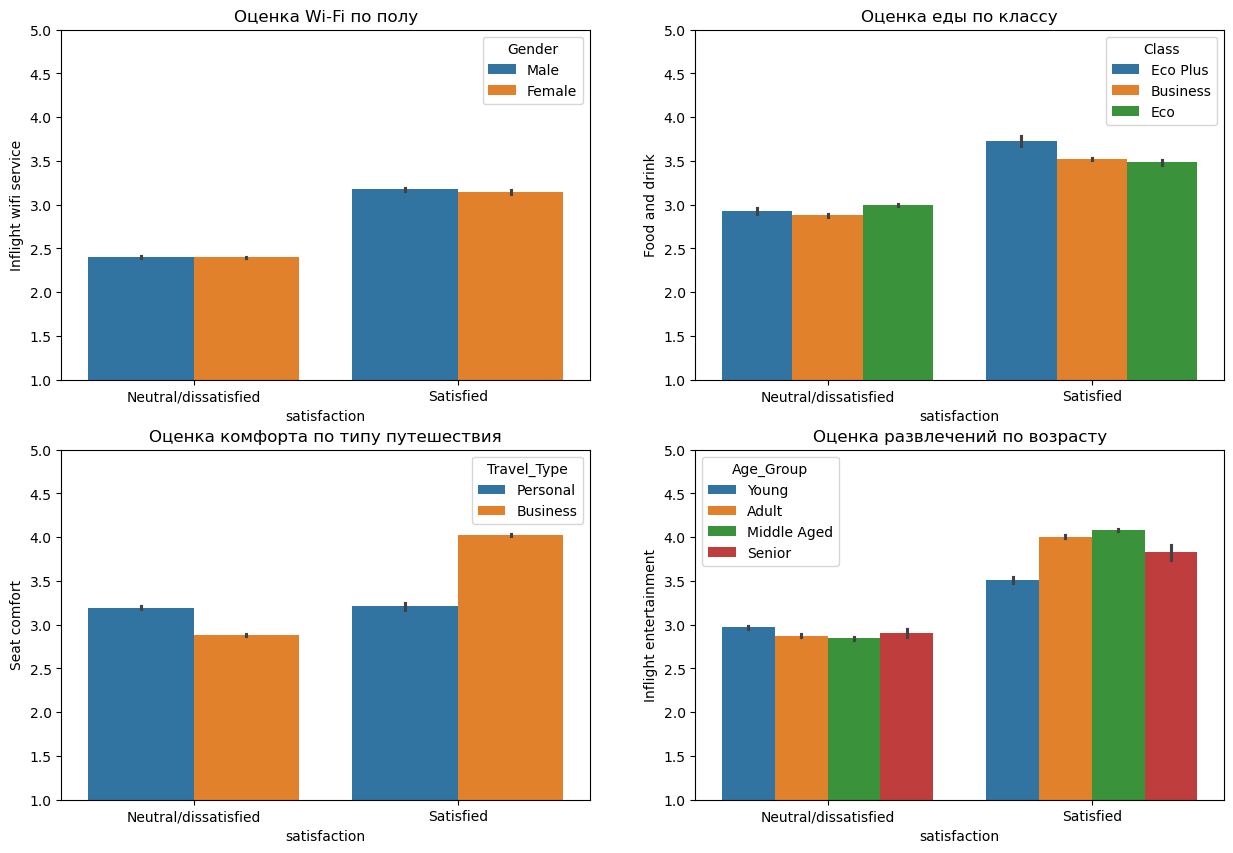

In [73]:
df_plot = df.copy()
df_plot['satisfaction'] = df_plot['satisfaction_label'].map({0: 'Neutral/dissatisfied', 1: 'Satisfied'})
df_plot['Class'] = df_plot['Class_Label'].map({1: 'Business', 2: 'Eco', 3: 'Eco Plus'})
df_plot['Travel_Type'] = df_plot['Type_of_Travel_Label'].map({0: 'Business', 1: 'Personal'})

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.barplot(data=df_plot, x='satisfaction', y='Inflight wifi service', hue='Gender', ax=axes[0,0])
axes[0,0].set_title('Оценка Wi-Fi по полу')
axes[0,0].set_ylim(1, 5)

sns.barplot(data=df_plot, x='satisfaction', y='Food and drink', hue='Class', ax=axes[0,1])
axes[0,1].set_title('Оценка еды по классу')
axes[0,1].set_ylim(1, 5)

sns.barplot(data=df_plot, x='satisfaction', y='Seat comfort', hue='Travel_Type', ax=axes[1,0])
axes[1,0].set_title('Оценка комфорта по типу путешествия')
axes[1,0].set_ylim(1, 5)

sns.barplot(data=df_plot, x='satisfaction', y='Inflight entertainment', hue='Age_Group', ax=axes[1,1])
axes[1,1].set_title('Оценка развлечений по возрасту')
axes[1,1].set_ylim(1, 5)

plt.show()

<Axes: >

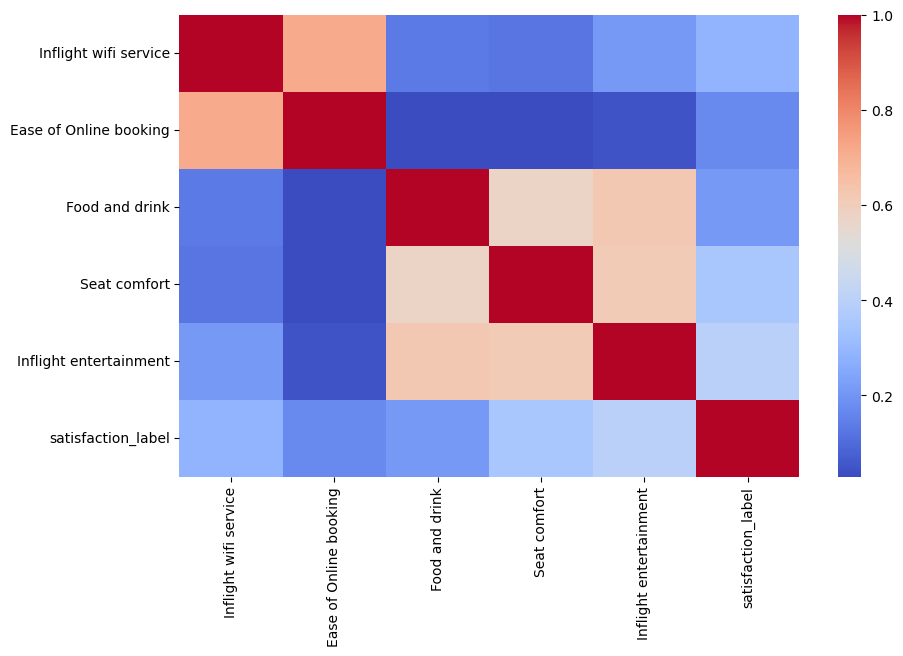

In [74]:
service_columns = ['Inflight wifi service', 'Ease of Online booking', 
                   'Food and drink', 'Seat comfort', 'Inflight entertainment']
plt.figure(figsize=(10, 6))
sns.heatmap(df[service_columns + ['satisfaction_label']].corr(), cmap='coolwarm')

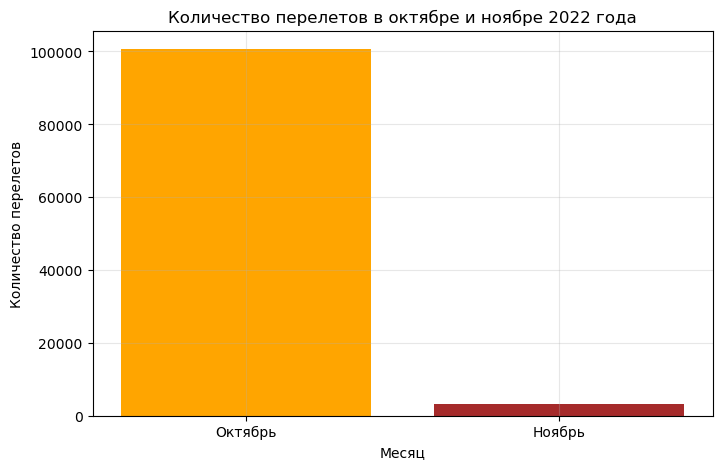

In [76]:
flights_oct_nov = df[(df['Flight_Year'] == 2022) & (df['Flight_Month'].isin([10, 11]))]
monthly_flights = flights_oct_nov['Flight_Month'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(monthly_flights.index, monthly_flights.values, color=['orange', 'brown'])
plt.title('Количество перелетов в октябре и ноябре 2022 года')
plt.xlabel('Месяц')
plt.ylabel('Количество перелетов')
plt.xticks([10, 11], ['Октябрь', 'Ноябрь'])
plt.grid(True, alpha=0.3)
plt.show()

In [84]:
df_cleaned = df[df['Flight_Month'] != 11]

In [90]:
#КРАТКИЙ ОТЧЕТ ПО АНАЛИЗУ
# В основном, в данных, представленных в таблице, не преобладали пропуски в столбцах за исключением: 'Leg room service', 'Baggage handling', 'Arrival Delay in Minutes'.
#Пустые строки в этих столбцах были заменены на средние или наиболее вероятные значения для упрощения обработки данных в дальнейшем.
# Также были удалены выбросы по возрасту и по датам. В основном, информация пердставлена по перелетам в октябре, однако где-то встречался ноябрь, что можно посчитать за выброс поэтому он также был удален.
# Все нечисловые данные были переведены в числовые посредством обработки категориальных жлементов
# Были построены 4 столбчатых графика, на которых видна средняя оценка удовлетворенности пассажиров по разным показателям.
# Также была построена корреляционный график, демонстрирующий корреляцию оценок пассажиров по разным показателям.